In [2]:
import os
import sys
# add the 'src' directory as one where we can import modules
PROJ_ROOT = os.path.join(os.pardir)
src_dir = os.path.join(PROJ_ROOT, 'src')
sys.path.append(src_dir)

print(os.getcwd())
print(sys.path)

import IPython.extensions.autoreload
%load_ext autoreload
%autoreload 2

# import my method from the source code
from ingest import data_workflow
from dataset import analyze, detect_elapsed_time_anomalies, resample
import matplotlib.pyplot as plt

Failed to read module file 'C:\Users\Loris Amabile\AppData\Roaming\uv\python\cpython-3.12.12-windows-x86_64-none\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Loris Amabile\Documents\c_market\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Loris Amabile\Documents\c_market\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Loris Amabile\AppData\Roaming\uv\python\cpython-3.12.12-windows-x86_64-none\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importl

c:\Users\Loris Amabile\Documents\c_market\notebooks
['C:\\Users\\Loris Amabile\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\python312.zip', 'C:\\Users\\Loris Amabile\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\DLLs', 'C:\\Users\\Loris Amabile\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib', 'C:\\Users\\Loris Amabile\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none', 'c:\\Users\\Loris Amabile\\Documents\\c_market\\.venv', '', 'c:\\Users\\Loris Amabile\\Documents\\c_market\\.venv\\Lib\\site-packages', 'c:\\Users\\Loris Amabile\\Documents\\c_market\\.venv\\Lib\\site-packages\\win32', 'c:\\Users\\Loris Amabile\\Documents\\c_market\\.venv\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\Loris Amabile\\Documents\\c_market\\.venv\\Lib\\site-packages\\Pythonwin', '..\\src']


c:\Users\Loris Amabile\Documents\c_market\notebooks\..\src\ingest.py:29: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  parsed = pd.to_datetime(df[col], errors="coerce", dayfirst=True)


count                        37058
mean     0 days 00:00:12.466134653
std      0 days 00:01:05.259632025
min         0 days 00:00:01.005000
25%                0 days 00:00:03
50%         0 days 00:00:06.992000
75%         0 days 00:00:09.994000
max         0 days 01:29:01.994000
Name: timestamp_diff_col, dtype: object
---------------- elapsed anomalies : 31198 (expected 0 days 00:00:02) ------------


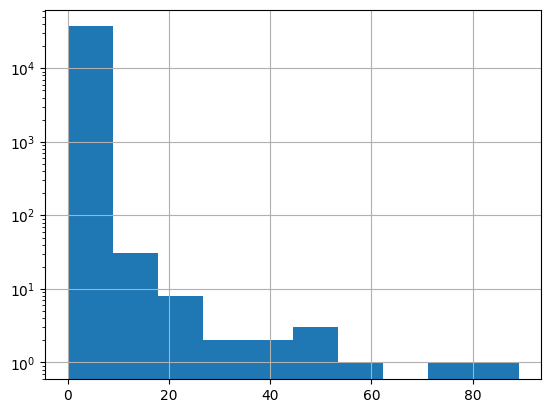

In [3]:
y = data_workflow("inariz")

# include the unit into the main column name
y = y.rename(columns={"Valeur": "steam_production_(m3/h)"})

# for other columns, keep only numerical columns
# set the timestamp as a column with a standard name, not as the index
y = y.drop(columns=["Unité"])


analyze(y)
elapsed_anomalies, expected_delta = detect_elapsed_time_anomalies(y, timestamp_col="measured_at")
# target
y = y[["measured_at", "steam_production_(m3/h)"]] #todo check, useless je pense (et faux ?)
y_10min = resample(y, desired_timedelta="10min", aggregate_function="mean")
y_15min = resample(y, desired_timedelta="15min", aggregate_function="mean")

Verify that the average is done correctly between [00:00; 00:15[

In [16]:
import datetime 
y_15min[(y_15min["measured_at"] >= datetime.datetime(2025, 12, 15, 0, 0, 0)) & (y_15min["measured_at"] <= datetime.datetime(2025, 12, 15, 1, 0, 0))]

TypeError: Invalid comparison between dtype=datetime64[ns, UTC] and datetime

In [ ]:
y[(y["measured_at"] >= datetime.datetime(2025, 12, 15, 0, 15, 0)) & (y["measured_at"] < datetime.datetime(2025, 12, 15, 0, 30, 0))]["steam_production_(m3/h)"].describe()

In [4]:
# plot original and resampled timeseries, to check the choice of aggregate_function
import PyQt6
%matplotlib qt
fig, ax = plt.subplots()

ax.plot(y["measured_at"], y["steam_production_(m3/h)"], label="original")
ax.step(y_10min["measured_at"], y_10min["steam_production_(m3/h)"], label="resampled 10 min", where="post")
ax.step(y_15min["measured_at"], y_15min["steam_production_(m3/h)"], label="resampled 15 min", where="post")
ax.set_ylabel("Value")
# ax.set_title(path.name)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

Try simplest forms of prediction

In [102]:
from predict import simple_copy, copy_median_values
import datetime

# y_copy1day = simple_copy(y_15min, "measured_at", "steam_production_(m3/h)", datetime.date(2025,12,15), datetime.date(2025,12,16))
# y_copy1week = simple_copy(y_15min, "measured_at", "steam_production_(m3/h)", datetime.date(2025,12,15), datetime.date(2025,12,20))

y_median1day = copy_median_values(y_15min, "measured_at", "steam_production_(m3/h)", use_holidays=False, use_weekdays=True, use_hours=True, extension="jour")
# y_median1week = copy_median_values(y_15min, "measured_at", "steam_production_(m3/h)", use_holidays=False, use_weekdays=True, use_hours=True, extension="semaine")


TEMP verification pour simple_copy

In [ ]:
from datetime import tzinfo
start = datetime.datetime(2025,12,15)
start = pd.to_datetime(start).tz_localize("Europe/Paris").tz_convert("UTC")
start

Timestamp('2025-12-14 23:00:00+0000', tz='UTC')

In [ ]:
y_copy1day[y_copy1day["measured_at"]==start]

,measured_at,steam_production_(m3/h)
0,2025-12-14 23:00:00+00:00,675.168389


In [ ]:
y_copy1day.iloc[-100:-90].measured_at.dt.weekday

511    5
512    5
513    5
514    5
515    5
516    5
517    5
518    6
519    6
520    6
Name: measured_at, dtype: int32

In [101]:
# y_copy1week[y_copy1week.measured_at == start_new_1week]
# y_copy1week.iloc[len(y_15min)-3:len(y_15min)+3]
print(y_copy1week.iloc[len(y_15min)].measured_at.weekday())
start  = datetime.date(2025,12,15)
start = pd.to_datetime(start, errors="coerce")
start = start.tz_localize(source_timezone)
start = start.tz_convert("UTC")

print(y_15min[y_15min.measured_at == start].measured_at.dt.weekday)


6
0    6
Name: measured_at, dtype: int32


temp vérification copy median

In [103]:
y_median1day.iloc[len(y_15min)-3:len(y_15min)+3]

,measured_at,steam_production_(m3/h)
511,2025-12-20 06:45:00+00:00,530.893062
512,2025-12-20 07:00:00+00:00,533.215119
513,2025-12-20 07:15:00+00:00,832.717848
514,2025-12-20 07:30:00+00:00,682.966483
515,2025-12-20 07:45:00+00:00,682.966483
516,2025-12-20 08:00:00+00:00,582.585169


copy_median_value copie forcément juste après la fin du df inial
ce que je dois vérifier, c'est si, pour faire la valeur du 2025-12-20 07:30:00+00:00, il a bien pris la mediane des jours et weekdays et créneaux pertinents.